In [1]:
!pip install pandas sqlalchemy pymysql

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("Mabutalib0110@")
host = "127.0.0.1"
port = "3306"
database = "olist_ecommerce"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

try:
    with engine.connect() as conn:
        print("✅ Connection successful!")
except Exception as e:
    print("❌ Error:", e)

✅ Connection successful!


In [3]:
import pandas as pd

df = pd.read_csv(r"E:\DATA ANALYTICS\Projects\E-Commerce\Datasets\olist_geolocation_dataset.csv")

print("Total rows:", len(df))
df.head()

Total rows: 1000163


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [4]:
from sqlalchemy import text

# First empty the table
with engine.connect() as conn:
    conn.execute(text("TRUNCATE TABLE geolocation"))
    conn.commit()

# Fast import
df.to_sql(
    'geolocation',
    con=engine,
    if_exists='append',
    index=False,
    chunksize=5000,
    method='multi'
)

print("✅ Geolocation data imported successfully!")

✅ Geolocation data imported successfully!


In [5]:
import pandas as pd
from sqlalchemy import text
import time

# folder path
folder = r"E:\DATA ANALYTICS\Projects\E-Commerce\Datasets"

# Table order zaroori hai (for foreign key dependency)
tables_to_load = [
    ("customers", "olist_customers_dataset.csv"),
    ("sellers", "olist_sellers_dataset.csv"),
    ("product_category_name_translation", "product_category_name_translation.csv"),
    ("products", "olist_products_dataset.csv"),
    ("geolocation", "olist_geolocation_dataset.csv"),
    ("orders", "olist_orders_dataset.csv"),
    ("order_items", "olist_order_items_dataset.csv"),
    ("order_payments", "olist_order_payments_dataset.csv"),
    ("order_reviews", "olist_order_reviews_dataset.csv")
]

for table_name, file_name in tables_to_load:
    start = time.time()
    print(f"⏳ Loading {table_name} ...")
    
    # CSV padho
    df = pd.read_csv(f"{folder}\\{file_name}")
    
    # First empty the table (FK checks temporarily off karke, taaki order na todhna pade)
    with engine.connect() as conn:
        conn.execute(text("SET FOREIGN_KEY_CHECKS=0"))
        conn.execute(text(f"TRUNCATE TABLE {table_name}"))
        conn.execute(text("SET FOREIGN_KEY_CHECKS=1"))
        conn.commit()
    
    df.to_sql(
        table_name,
        con=engine,
        if_exists='append',
        index=False,
        chunksize=5000,
        method='multi'
    )
    
    elapsed = time.time() - start
    print(f"✅ {table_name}: {len(df)} rows loaded in {elapsed:.1f} sec\n")

print("🎉 Saari tables successfully load ho gayi!")

⏳ Loading customers ...
✅ customers: 99441 rows loaded in 17.9 sec

⏳ Loading sellers ...
✅ sellers: 3095 rows loaded in 0.6 sec

⏳ Loading product_category_name_translation ...
✅ product_category_name_translation: 71 rows loaded in 0.1 sec

⏳ Loading products ...
✅ products: 32951 rows loaded in 8.6 sec

⏳ Loading geolocation ...
✅ geolocation: 1000163 rows loaded in 145.8 sec

⏳ Loading orders ...
✅ orders: 99441 rows loaded in 26.9 sec

⏳ Loading order_items ...
✅ order_items: 112650 rows loaded in 27.0 sec

⏳ Loading order_payments ...
✅ order_payments: 103886 rows loaded in 16.0 sec

⏳ Loading order_reviews ...
✅ order_reviews: 99224 rows loaded in 19.6 sec

🎉 Saari tables successfully load ho gayi!


In [6]:
# Import or Load the data

customers = pd.read_sql("SELECT * FROM customers", con=engine)
sellers = pd.read_sql("SELECT * FROM sellers", con=engine)
products = pd.read_sql("SELECT * FROM products", con=engine)
category_translation = pd.read_sql("SELECT * FROM product_category_name_translation", con=engine)
geolocation = pd.read_sql("SELECT * FROM geolocation", con=engine)
orders = pd.read_sql("SELECT * FROM orders", con=engine)
order_items = pd.read_sql("SELECT * FROM order_items", con=engine)
order_payments = pd.read_sql("SELECT * FROM order_payments", con=engine)
order_reviews = pd.read_sql("SELECT * FROM order_reviews", con=engine)


tables = {
    "customers": customers, "sellers": sellers, "products": products,
    "category_translation": category_translation, "geolocation": geolocation,
    "orders": orders, "order_items": order_items,
    "order_payments": order_payments, "order_reviews": order_reviews
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
sellers: (3095, 4)
products: (32951, 9)
category_translation: (71, 2)
geolocation: (1000163, 6)
orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)


In [7]:
# find how many missing values

for name, df in tables.items():
    print(f"\n{name}")
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) == 0:
        print("No missing values")
    else:
        print(nulls)


customers
No missing values

sellers
No missing values

products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

category_translation
No missing values

geolocation
No missing values

orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

order_items
No missing values

order_payments
No missing values

order_reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [8]:
# 1. PRODUCTS
# products                      missing values
# product_category_name         610
# product_name_lenght           610
# product_description_lenght    610
# product_photos_qty            610
# product_weight_g                2
# product_length_cm               2
# product_height_cm               2
# product_width_cm                2

products['product_category_name'] = products['product_category_name'].fillna('unknown')
products['product_name_lenght'] = products['product_name_lenght'].fillna(0)
products['product_description_lenght'] = products['product_description_lenght'].fillna(0)
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)

# Weight/dimensions - sirf 2 rows missing hain, go with median
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products[col] = products[col].fillna(products[col].median())

print("Products missing after cleaning:")
print(products.isnull().sum()[products.isnull().sum() > 0])

Products missing after cleaning:
Series([], dtype: int64)


In [9]:
# 2. ORDERS
# Delivery date columns is as itis (NaN = not delivered yet)
# craete a flag column 
orders['is_delivered'] = orders['order_delivered_customer_date'].notnull()

print("\nDelivered vs Not Delivered:")
print(orders['is_delivered'].value_counts())


Delivered vs Not Delivered:
is_delivered
True     96476
False     2965
Name: count, dtype: int64


In [10]:
# 3. ORDER_REVIEWS
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].fillna('No title')
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna('No comment')

print("\nOrder reviews missing after cleaning:")
print(order_reviews.isnull().sum()[order_reviews.isnull().sum() > 0])


Order reviews missing after cleaning:
Series([], dtype: int64)


In [11]:
for name, df in tables.items():
    df.info()
    print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   object
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: object(4)
memory usage: 96.8+ KB


<class 'pan

In [12]:
# CHeck duplicates

for name, df in tables.items():
    dup_count = df.duplicated().sum()
    print(f"{name}: {dup_count} duplicate rows")

customers: 0 duplicate rows
sellers: 0 duplicate rows
products: 0 duplicate rows
category_translation: 0 duplicate rows
geolocation: 0 duplicate rows
orders: 0 duplicate rows
order_items: 0 duplicate rows
order_payments: 0 duplicate rows
order_reviews: 0 duplicate rows


In [13]:
# Feature Engineering: Delivery Metrics

# 1. Delivery delay (actual delivery - estimated delivery)
# Positive value = late, Negative value = early
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# 2. Is the order late? (True/False flag)
orders['is_late'] = orders['delivery_delay_days'] > 0

# 3. How many days did it take from purchase to actual delivery? 
orders['order_to_delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# 4. How many days did approval take (purchase to approval)?
orders['approval_time_days'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
).dt.days

# Check results
orders[['order_id', 'order_status', 'is_delivered', 'delivery_delay_days',
        'is_late', 'order_to_delivery_days', 'approval_time_days']].head(10)

,order_id,order_status,is_delivered,delivery_delay_days,is_late,order_to_delivery_days,approval_time_days
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,True,-9.0,False,7.0,0.0
1,00018f77f2f0320c557190d7a144bdd3,delivered,True,-3.0,False,16.0,0.0
2,000229ec398224ef6ca0657da4fc703e,delivered,True,-14.0,False,7.0,0.0
3,00024acbcdf0a6daa1e931b038114c75,delivered,True,-6.0,False,6.0,0.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,True,-16.0,False,25.0,0.0
5,00048cc3ae777c65dbb7d2a0634bc1ea,delivered,True,-15.0,False,6.0,1.0
6,00054e8431b9d7675808bcb819fb4a32,delivered,True,-17.0,False,8.0,0.0
7,000576fe39319847cbb9d288c5617fa6,delivered,True,-16.0,False,5.0,1.0
8,0005a1a1728c9d785b8e2b08b904576c,delivered,True,0.0,False,9.0,0.0
9,0005f50442cb953dcd1d21e1fb923495,delivered,True,-19.0,False,2.0,0.0


In [14]:
# ---------- Order-level aggregation from order_items ----------
# Ek order mein multiple items ho sakte hain, isliye order-level summary h

order_items_summary = order_items.groupby('order_id').agg(
    total_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()

order_items_summary['total_order_value'] = (
    order_items_summary['total_price'] + order_items_summary['total_freight']
)

print("Order items summary shape:", order_items_summary.shape)
order_items_summary.head()

Order items summary shape: (98666, 5)


,order_id,total_items,total_price,total_freight,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04


In [15]:
# ---------- Order-level aggregation from order_payments ----------
# Ek order mein multiple payment rows ho sakte hain (installments), isliye aggregate

order_payments_summary = order_payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max'),
    payment_type=('payment_type', 'first')   # sabse pehla payment type le lo
).reset_index()

print("Order payments summary shape:", order_payments_summary.shape)
order_payments_summary.head()

Order payments summary shape: (99440, 4)


,order_id,total_payment_value,payment_installments_max,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [16]:
# ---------- Building fact_orders ----------

fact_orders = orders.merge(order_items_summary, on='order_id', how='left')
fact_orders = fact_orders.merge(order_payments_summary, on='order_id', how='left')

# Customer se surrogate-friendly link ke liye customer_unique_id bhi le aate hain
fact_orders = fact_orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_id', how='left'
)

print("fact_orders shape:", fact_orders.shape)
fact_orders.head()

fact_orders shape: (99441, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,delivery_delay_days,...,total_items,total_price,total_freight,total_order_value,total_payment_value,payment_installments_max,payment_type,customer_unique_id,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,True,-9.0,...,1.0,58.90,13.29,72.19,72.19,2.0,credit_card,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,True,-3.0,...,1.0,239.90,19.93,259.83,259.83,3.0,credit_card,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,True,-14.0,...,1.0,199.00,17.87,216.87,216.87,5.0,credit_card,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,True,-6.0,...,1.0,12.99,12.79,25.78,25.78,2.0,credit_card,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,True,-16.0,...,1.0,199.90,18.14,218.04,218.04,3.0,credit_card,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP


In [17]:
type(orders)

pandas.core.frame.DataFrame

In [18]:
orders = pd.read_sql("SELECT * FROM orders", con=engine)

# Feature engineering wapas karna padega (kyunki naya fresh orders load hua hai)
orders['is_delivered'] = orders['order_delivered_customer_date'].notnull()

orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

orders['is_late'] = orders['delivery_delay_days'] > 0

orders['order_to_delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

orders['approval_time_days'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
).dt.days

print(type(orders))
print(orders.shape)
orders.head()

<class 'pandas.core.frame.DataFrame'>
(99441, 13)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,delivery_delay_days,is_late,order_to_delivery_days,approval_time_days
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,True,-9.0,False,7.0,0.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,True,-3.0,False,16.0,0.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,True,-14.0,False,7.0,0.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,True,-6.0,False,6.0,0.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,True,-16.0,False,25.0,0.0


In [19]:
fact_orders = orders.merge(order_items_summary, on='order_id', how='left')
fact_orders = fact_orders.merge(order_payments_summary, on='order_id', how='left')

fact_orders = fact_orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_id', how='left'
)

print("fact_orders shape:", fact_orders.shape)
fact_orders.head()

fact_orders shape: (99441, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,delivery_delay_days,...,total_items,total_price,total_freight,total_order_value,total_payment_value,payment_installments_max,payment_type,customer_unique_id,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,True,-9.0,...,1.0,58.90,13.29,72.19,72.19,2.0,credit_card,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,True,-3.0,...,1.0,239.90,19.93,259.83,259.83,3.0,credit_card,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,True,-14.0,...,1.0,199.00,17.87,216.87,216.87,5.0,credit_card,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,True,-6.0,...,1.0,12.99,12.79,25.78,25.78,2.0,credit_card,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,True,-16.0,...,1.0,199.90,18.14,218.04,218.04,3.0,credit_card,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP


In [20]:
print("Original orders count:", len(orders))
print("fact_orders count:", len(fact_orders))

Original orders count: 99441
fact_orders count: 99441


In [21]:
# dim_customers
dim_customers = customers[['customer_unique_id', 'customer_city', 'customer_state']].copy()

# Sirf customer_unique_id ke basis pe deduplicate krna h (har customer ki pehli city/state rakha)
dim_customers = dim_customers.drop_duplicates(subset='customer_unique_id', keep='first').reset_index(drop=True)

dim_customers['customer_key'] = dim_customers.index + 1
dim_customers['customer_label'] = 'CUST-' + dim_customers['customer_key'].astype(str).str.zfill(5)

dim_customers = dim_customers[['customer_key', 'customer_label', 'customer_unique_id', 'customer_city', 'customer_state']]

print("dim_customers shape:", dim_customers.shape)

# Verify: customer_unique_id now unique
print("Unique customer_unique_id count:", dim_customers['customer_unique_id'].nunique())
print("Total rows:", len(dim_customers))
# Dono numbers equal hone chahiye

dim_customers shape: (96096, 5)
Unique customer_unique_id count: 96096
Total rows: 96096


In [22]:
# ---------- dim_products ----------
dim_products = products.merge(
    category_translation, on='product_category_name', how='left'
)
dim_products['product_category_english'] = dim_products['product_category_name_english'].fillna(dim_products['product_category_name'])

dim_products = dim_products[[
    'product_id', 'product_category_english', 'product_weight_g',
    'product_length_cm', 'product_height_cm', 'product_width_cm'
]].drop_duplicates(subset='product_id').reset_index(drop=True)

dim_products['product_key'] = dim_products.index + 1
dim_products['product_label'] = 'PROD-' + dim_products['product_key'].astype(str).str.zfill(5)

dim_products = dim_products[['product_key', 'product_label', 'product_id', 'product_category_english',
                              'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']]

print("dim_products shape:", dim_products.shape)
dim_products.head()

dim_products shape: (32951, 8)


,product_key,product_label,product_id,product_category_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1,PROD-00001,00066f42aeeb9f3007548bb9d3f33c38,perfumery,300.0,20.0,16.0,16.0
1,2,PROD-00002,00088930e925c41fd95ebfe695fd2655,auto,1225.0,55.0,10.0,26.0
2,3,PROD-00003,0009406fd7479715e4bef61dd91f2462,bed_bath_table,300.0,45.0,15.0,35.0
3,4,PROD-00004,000b8f95fcb9e0096488278317764d19,housewares,550.0,19.0,24.0,12.0
4,5,PROD-00005,000d9be29b5207b54e86aa1b1ac54872,watches_gifts,250.0,22.0,11.0,15.0


In [23]:
# ---------- dim_sellers ----------
dim_sellers = sellers[['seller_id', 'seller_city', 'seller_state']].drop_duplicates().reset_index(drop=True)
dim_sellers['seller_key'] = dim_sellers.index + 1
dim_sellers['seller_label'] = 'SELL-' + dim_sellers['seller_key'].astype(str).str.zfill(5)

dim_sellers = dim_sellers[['seller_key', 'seller_label', 'seller_id', 'seller_city', 'seller_state']]

print("dim_sellers shape:", dim_sellers.shape)
dim_sellers.head()

dim_sellers shape: (3095, 5)


,seller_key,seller_label,seller_id,seller_city,seller_state
0,1,SELL-00001,0015a82c2db000af6aaaf3ae2ecb0532,santo andre,SP
1,2,SELL-00002,001cca7ae9ae17fb1caed9dfb1094831,cariacica,ES
2,3,SELL-00003,001e6ad469a905060d959994f1b41e4f,sao goncalo,RJ
3,4,SELL-00004,002100f778ceb8431b7a1020ff7ab48f,franca,SP
4,5,SELL-00005,003554e2dce176b5555353e4f3555ac8,goiania,GO


In [24]:
# ---------- dim_date ----------
min_date = orders['order_purchase_timestamp'].min().date()
max_date = orders['order_estimated_delivery_date'].max().date()

dim_date = pd.DataFrame({'date': pd.date_range(start=min_date, end=max_date, freq='D')})
dim_date['date_key'] = dim_date['date'].dt.strftime('%Y%m%d').astype(int)
dim_date['year'] = dim_date['date'].dt.year
dim_date['month'] = dim_date['date'].dt.month
dim_date['month_name'] = dim_date['date'].dt.strftime('%b')
dim_date['quarter'] = dim_date['date'].dt.quarter
dim_date['day'] = dim_date['date'].dt.day
dim_date['weekday_name'] = dim_date['date'].dt.strftime('%A')

dim_date = dim_date[['date_key', 'date', 'year', 'month', 'month_name', 'quarter', 'day', 'weekday_name']]

print("dim_date shape:", dim_date.shape)
dim_date.head()

dim_date shape: (800, 8)


,date_key,date,year,month,month_name,quarter,day,weekday_name
0,20160904,2016-09-04,2016,9,Sep,3,4,Sunday
1,20160905,2016-09-05,2016,9,Sep,3,5,Monday
2,20160906,2016-09-06,2016,9,Sep,3,6,Tuesday
3,20160907,2016-09-07,2016,9,Sep,3,7,Wednesday
4,20160908,2016-09-08,2016,9,Sep,3,8,Thursday


In [25]:
# ---------- Rebuild fact_orders cleanly ----------

fact_orders = orders.merge(order_items_summary, on='order_id', how='left')
fact_orders = fact_orders.merge(order_payments_summary, on='order_id', how='left')

fact_orders = fact_orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id', how='left'
)

# Ab dim_customers (FIXED wala) se customer_key lao
fact_orders = fact_orders.merge(
    dim_customers[['customer_key', 'customer_unique_id']],
    on='customer_unique_id', how='left'
)

# Seller & product key (pehle jaisa hi)
order_seller_map = order_items.groupby('order_id')['seller_id'].first().reset_index()
fact_orders = fact_orders.merge(order_seller_map, on='order_id', how='left')
fact_orders = fact_orders.merge(dim_sellers[['seller_key', 'seller_id']], on='seller_id', how='left')

order_product_map = order_items.groupby('order_id')['product_id'].first().reset_index()
fact_orders = fact_orders.merge(order_product_map, on='order_id', how='left')
fact_orders = fact_orders.merge(dim_products[['product_key', 'product_id']], on='product_id', how='left')

print("fact_orders shape:", fact_orders.shape)
print("Original orders count:", len(orders))
# Ye dono match karne chahiye ab

fact_orders shape: (99441, 26)
Original orders count: 99441


In [26]:
# ---------- Final fact_orders (clean column selection) ----------

fact_orders_final = fact_orders[[
    'order_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date',
    'is_delivered', 'is_late', 'delivery_delay_days', 'order_to_delivery_days', 'approval_time_days',
    'total_items', 'total_price', 'total_freight', 'total_order_value',
    'total_payment_value', 'payment_installments_max', 'payment_type',
    'customer_key', 'seller_key', 'product_key'
]]

print("fact_orders_final shape:", fact_orders_final.shape)
fact_orders_final.head()

fact_orders_final shape: (99441, 22)


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,is_late,delivery_delay_days,...,total_items,total_price,total_freight,total_order_value,total_payment_value,payment_installments_max,payment_type,customer_key,seller_key,product_key
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,True,False,-9.0,...,1.0,58.90,13.29,72.19,72.19,2.0,credit_card,23489,855.0,8629.0
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,True,False,-3.0,...,1.0,239.90,19.93,259.83,259.83,3.0,credit_card,858,2679.0,29598.0
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,True,False,-14.0,...,1.0,199.00,17.87,216.87,216.87,5.0,credit_card,38364,1118.0,25668.0
3,00024acbcdf0a6daa1e931b038114c75,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,True,False,-6.0,...,1.0,12.99,12.79,25.78,25.78,2.0,credit_card,80626,1920.0,15323.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,True,False,-16.0,...,1.0,199.90,18.14,218.04,218.04,3.0,credit_card,33958,2698.0,22080.0


In [28]:
import os

# Create a Folder jaha CSVs save hongi
output_folder = r"E:\DATA ANALYTICS\Projects\E-Commerce\Python"
os.makedirs(output_folder, exist_ok=True)

fact_orders_final.to_csv(f"{output_folder}\\fact_orders.csv", index=False)
dim_customers.to_csv(f"{output_folder}\\dim_customers.csv", index=False)
dim_products.to_csv(f"{output_folder}\\dim_products.csv", index=False)
dim_sellers.to_csv(f"{output_folder}\\dim_sellers.csv", index=False)
dim_date.to_csv(f"{output_folder}\\dim_date.csv", index=False)

print("✅ All files exported to:", output_folder)
for f in os.listdir(output_folder):
    print(" -", f)

✅ All files exported to: E:\DATA ANALYTICS\Projects\E-Commerce\Python
 - dim_customers.csv
 - dim_date.csv
 - dim_products.csv
 - dim_sellers.csv
 - fact_orders.csv


In [29]:
# Review score ko fact_orders mein add karna h

# Ek order mein kabhi-kabhi 1 se zyada review ho sakte hain, isliye average le lete hain
review_summary = order_reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

fact_orders_final = fact_orders_final.merge(review_summary, on='order_id', how='left')

print("fact_orders_final shape:", fact_orders_final.shape)
print("\nMissing review scores:", fact_orders_final['review_score'].isnull().sum())
fact_orders_final.head()

fact_orders_final shape: (99441, 23)

Missing review scores: 768


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,is_late,delivery_delay_days,...,total_price,total_freight,total_order_value,total_payment_value,payment_installments_max,payment_type,customer_key,seller_key,product_key,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,True,False,-9.0,...,58.90,13.29,72.19,72.19,2.0,credit_card,23489,855.0,8629.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,True,False,-3.0,...,239.90,19.93,259.83,259.83,3.0,credit_card,858,2679.0,29598.0,4.0
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,True,False,-14.0,...,199.00,17.87,216.87,216.87,5.0,credit_card,38364,1118.0,25668.0,5.0
3,00024acbcdf0a6daa1e931b038114c75,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,True,False,-6.0,...,12.99,12.79,25.78,25.78,2.0,credit_card,80626,1920.0,15323.0,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,True,False,-16.0,...,199.90,18.14,218.04,218.04,3.0,credit_card,33958,2698.0,22080.0,5.0


In [31]:
fact_orders_final.to_csv(f"{output_folder}\\fact_orders.csv", index=False)
print("✅ fact_orders.csv updated with review_score")

✅ fact_orders.csv updated with review_score


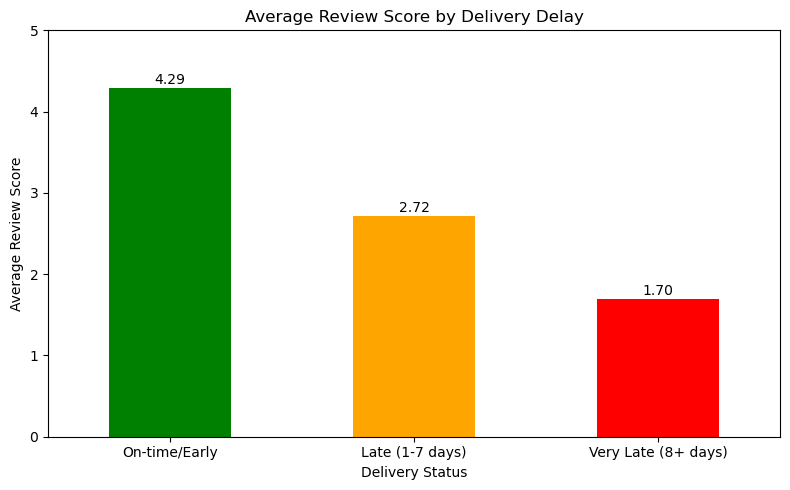

delay_bucket
On-time/Early          4.290450
Late (1-7 days)        2.715417
Very Late (8+ days)    1.698059
Name: review_score, dtype: float64


In [32]:
import matplotlib.pyplot as plt

# Sirf delivered orders lo (jinke paas review score hai)
delivered = fact_orders_final[fact_orders_final['is_delivered'] & fact_orders_final['review_score'].notnull()].copy()

# Delay ko buckets mein rakhaa
def delay_bucket(days):
    if days <= 0:
        return 'On-time/Early'
    elif days <= 7:
        return 'Late (1-7 days)'
    else:
        return 'Very Late (8+ days)'

delivered['delay_bucket'] = delivered['delivery_delay_days'].apply(delay_bucket)

# Average review score per bucket
avg_review = delivered.groupby('delay_bucket')['review_score'].mean().reindex(
    ['On-time/Early', 'Late (1-7 days)', 'Very Late (8+ days)']
)

# Plot
plt.figure(figsize=(8,5))
avg_review.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Review Score by Delivery Delay')
plt.ylabel('Average Review Score')
plt.xlabel('Delivery Status')
plt.xticks(rotation=0)
plt.ylim(0, 5)
for i, v in enumerate(avg_review):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

print(avg_review)